# Exploração do Dataset CWRU e Geração de Escalogramas via CWT

**Projeto:** Diagnóstico de Falhas em Rolamentos via CNN + Transformada Wavelet Contínua  
**Dataset:** Case Western Reserve University (CWRU) Bearing Data  
**Objetivo:** Explorar os sinais de vibração do dataset CWRU, gerar escalogramas por meio da
Transformada Wavelet Contínua (CWT) e preparar imagens para a Rede Neural Convolucional (CNN).

---

## 1. Importação de Módulos e Parâmetros do Projeto

Importamos as bibliotecas e as configurações centrais diretamente do pacote `src` do projeto,
garantindo que qualquer alteração em `src/config.py` seja refletida automaticamente aqui.

In [1]:
import sys
from pathlib import Path

# Adicionar a raiz do projeto ao sys.path para importar os módulos da pasta src
BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import matplotlib.pyplot as plt

# Importar configurações e funções dos módulos .py
from src.config import FS, WINDOW_SIZE, WAVELET, FREQ_MIN, FREQ_MAX, IMG_HEIGHT, CLASSES
from src.dataset import load_cwru_mat_file, load_class_windows
from src.cwt_processor import compute_cwt, save_scalogram_png
from src.visualization import plot_monograph_figure

## 2. Resumo das Configurações Globais (`src/config.py`)

Exibimos os parâmetros importados para verificação:

In [2]:
print('=== PARÂMETROS DO PROJETO ===')
print(f'Taxa de Amostragem (FS) : {FS} Hz')
print(f'Tamanho da Janela       : {WINDOW_SIZE} amostras ({WINDOW_SIZE / FS * 1000:.1f} ms)')
print(f'Wavelet Mãe             : {WAVELET}')
print(f'Faixa de Frequência     : {FREQ_MIN} Hz a {FREQ_MAX} Hz')
print(f'Altura do Escalograma   : {IMG_HEIGHT} pixels')

=== PARÂMETROS DO PROJETO ===
Taxa de Amostragem (FS) : 12000 Hz
Tamanho da Janela       : 1024 amostras (85.3 ms)
Wavelet Mãe             : cmor1.5-1.0
Faixa de Frequência     : 10 Hz a 6000 Hz
Altura do Escalograma   : 224 pixels


## 3. Carregamento e Exploração de um Sinal CWRU

Utilizamos a função `load_cwru_mat_file` (do arquivo `src/dataset.py`) para carregar
o canal de vibração no **Drive End** (`_DE_time`).

In [3]:
# Caminho para um arquivo com falha na esfera (Ball)
caminho_mat = BASE_DIR / 'data' / 'ball' / 'B007_0HP_1797rpm.mat'

# Carregar sinal usando o módulo src/dataset.py
sinal = load_cwru_mat_file(caminho_mat)
janela_sinal = sinal[0:WINDOW_SIZE]

print(f'Comprimento total do sinal: {len(sinal)} amostras')
print(f'Janela extraída          : {len(janela_sinal)} amostras')

Comprimento total do sinal: 122571 amostras
Janela extraída          : 1024 amostras


## 4. Visualização no Padrão da Monografia (Figura 5)

Geramos o gráfico formatado chamando diretamente a função `plot_monograph_figure`
do módulo `src/visualization.py`.

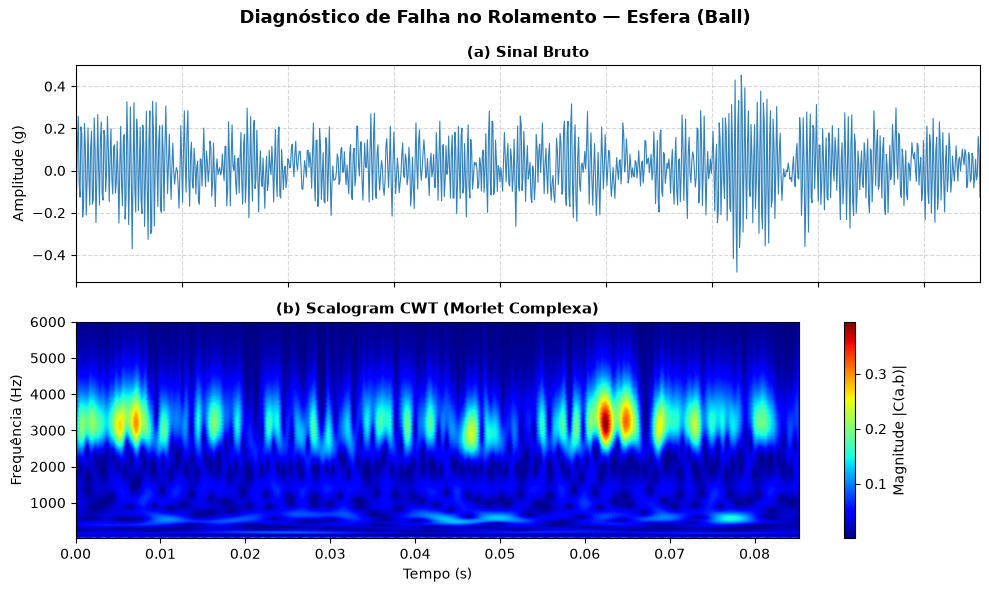

In [4]:
# Chama o módulo de visualização pronto do src/visualization.py
plot_monograph_figure(
    janela_sinal,
    title='Diagnóstico de Falha no Rolamento — Esfera (Ball)'
)

## 5. Geração Automatizada do Dataset de Imagens para a CNN

Para processar todas as 4 classes e gerar o dataset completo de imagens $224 \times 224$
dividido em `train`, `val` e `test`, podemos invocar o pipeline do `src/generate_dataset.py`:

In [5]:
from src.generate_dataset import process_and_generate_dataset

# Executa a geração completa do dataset de imagens (descomente para rodar)

process_and_generate_dataset()

 GERAÇÃO DO DATASET DE ESCALOGRAMAS (CWT -> CNN) 

[+] Processando classe: 'normal'...
    Total de janelas extraídas: 3310
    Generating train (2317 imagens)...


      normal/train: 100%|██████████| 2317/2317 [02:37<00:00, 14.69it/s]


    Generating val (496 imagens)...


      normal/val: 100%|██████████| 496/496 [00:31<00:00, 15.55it/s]


    Generating test (497 imagens)...


...

    Generating val (426 imagens)...


      ball/val: 100%|██████████| 426/426 [00:27<00:00, 15.50it/s]


    Generating test (426 imagens)...


      ball/test: 100%|██████████| 426/426 [00:27<00:00, 15.52it/s]


 Processo Concluído! Total de 11832 imagens salvas em:
 C:\Users\joaov\Desktop\bearing-fault-diagnosis\bearing-fault-diagnosis-cwt-cnn\data\processed
